In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles
import torch
import random
import torch.nn as nn
from torch import nn
from tqdm.auto import tqdm

In [2]:
n_samples = 1000
X,y = make_circles(n_samples=n_samples, noise=0.03, random_state=42)

In [3]:
print(f"First 5 features : {X[:5]}")
print(f"First 5 labels : {y[:5]}")

First 5 features : [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
First 5 labels : [1 1 1 1 0]


In [4]:
circles = pd.DataFrame({"X1":X[:,0], "X2":X[:,1], "label":y})
circles.head()

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0


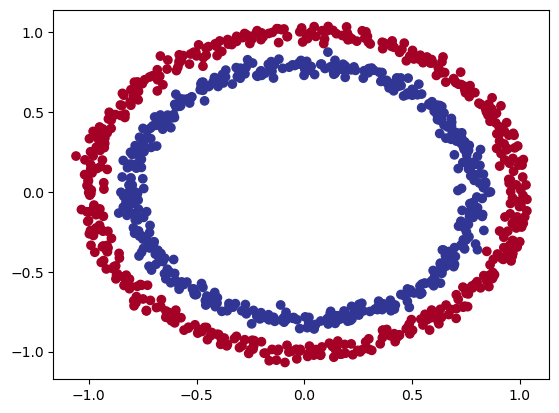

In [5]:
plt.scatter(x=X[:,0], y=X[:,1], c=y, cmap=plt.cm.RdYlBu)

In [6]:
if not isinstance(X, torch.Tensor):
    X = torch.tensor(X, dtype=torch.float32)
    y = torch.tensor(y, dtype=torch.float32)
    

In [8]:
X[:5], y[:5],X.type, y.type

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]),
 <function Tensor.type>,
 <function Tensor.type>)

In [18]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [12]:
class Repeat(nn.Module):
    def __init__(self,input_features,hidden_features,output_features):
        super().__init__()
        self.linear1 = nn.Linear(in_features = input_features,out_features=hidden_features)
        self.linear2 = nn.Linear(in_features=hidden_features,out_features=output_features)
        
    def forward(self,X):
       return self.linear2(self.linear1(X))
   
   

In [13]:
model_1 = Repeat(input_features=2,hidden_features=5,output_features=1)
model_1

Repeat(
  (linear1): Linear(in_features=2, out_features=5, bias=True)
  (linear2): Linear(in_features=5, out_features=1, bias=True)
)

In [14]:
model_1.state_dict()

OrderedDict([('linear1.weight',
              tensor([[-0.3208, -0.0514],
                      [-0.4422,  0.6233],
                      [-0.4321, -0.4569],
                      [-0.2179, -0.1570],
                      [ 0.1888,  0.6668]])),
             ('linear1.bias',
              tensor([ 0.3977, -0.2456, -0.2480, -0.6221,  0.3682])),
             ('linear2.weight',
              tensor([[-0.1236, -0.3101,  0.4326, -0.0372,  0.2476]])),
             ('linear2.bias', tensor([0.2566]))])

In [16]:
loss_fn  = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model_1.parameters(),lr=0.001)

In [17]:
with torch.inference_mode():
    y_logits = model_1(X)
    
y_logits[:5]

tensor([[0.2749],
        [0.2241],
        [0.2172],
        [0.1250],
        [0.5020]])

In [19]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

In [46]:
with torch.inference_mode():
    hello_pred = torch.round(torch.sigmoid(y_logits))

hello_pred[:10]

tensor([1., 0., 0., 0., 1., 0., 1., 1., 0., 0.])

In [45]:
y_test[:10]

tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])

In [20]:
def accuracy_fn(y_true,y_pred):
    correct = torch.eq(y_true,y_pred).sum().item()
    accuracy =  correct/len(y_true) * 100
    return accuracy

In [21]:
torch.manual_seed(42)
epochs = 1000
for epoch in tqdm(range(epochs)):
    model_1.train()
    
    
    y_logits = model_1(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))
    
    loss = loss_fn(y_logits,y_train)
    acc = accuracy_fn(y_true=y_train,y_pred = y_pred)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    
    model_1.eval()
    with torch.inference_mode():
        y_pred_test = model_1(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(y_pred_test))
        test_loss = loss_fn(y_pred_test,y_test)
        test_acc = accuracy_fn(y_true=y_test,y_pred=test_pred)
        
    if epoch % 10 == 0:
        print(f"Epoch : {epoch} | TrainLoss : {loss} | Train Acc : {acc} | Test Loss : {test_loss} | Test Acc : {test_acc}")

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch : 0 | TrainLoss : 0.707366406917572 | Train Acc : 50.0 | Test Loss : 0.7009982466697693 | Test Acc : 50.0
Epoch : 10 | TrainLoss : 0.7072519063949585 | Train Acc : 50.0 | Test Loss : 0.7008941173553467 | Test Acc : 50.0
Epoch : 20 | TrainLoss : 0.7071386575698853 | Train Acc : 50.0 | Test Loss : 0.7007909417152405 | Test Acc : 50.0
Epoch : 30 | TrainLoss : 0.7070265412330627 | Train Acc : 50.0 | Test Loss : 0.7006890177726746 | Test Acc : 50.0
Epoch : 40 | TrainLoss : 0.7069154381752014 | Train Acc : 50.0 | Test Loss : 0.7005881667137146 | Test Acc : 50.0
Epoch : 50 | TrainLoss : 0.7068054676055908 | Train Acc : 50.0 | Test Loss : 0.700488269329071 | Test Acc : 50.0
Epoch : 60 | TrainLoss : 0.7066965699195862 | Train Acc : 50.0 | Test Loss : 0.700389564037323 | Test Acc : 50.0
Epoch : 70 | TrainLoss : 0.7065887451171875 | Train Acc : 50.0 | Test Loss : 0.7002918720245361 | Test Acc : 50.0
Epoch : 80 | TrainLoss : 0.7064818739891052 | Train Acc : 50.0 | Test Loss : 0.7001951336860

In [22]:
def plot_decision_boundary(model: torch.nn.Module, X: torch.Tensor, y: torch.Tensor):
    """Plots decision boundaries of model predicting on X in comparison to y.

    Source - https://madewithml.com/courses/foundations/neural-networks/ (with modifications)
    """
    # Put everything to CPU (works better with NumPy + Matplotlib)
    model.to("cpu")
    X, y = X.to("cpu"), y.to("cpu")

    # Setup prediction boundaries and grid
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101), np.linspace(y_min, y_max, 101))

    # Make features
    X_to_pred_on = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()

    # Make predictions
    model.eval()
    with torch.inference_mode():
        y_logits = model(X_to_pred_on)

    # Test for multi-class or binary and adjust logits to prediction labels
    if len(torch.unique(y)) > 2:
        y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)  # mutli-class
    else:
        y_pred = torch.round(torch.sigmoid(y_logits))  # binary

    # Reshape preds and plot
    y_pred = y_pred.reshape(xx.shape).detach().numpy()
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

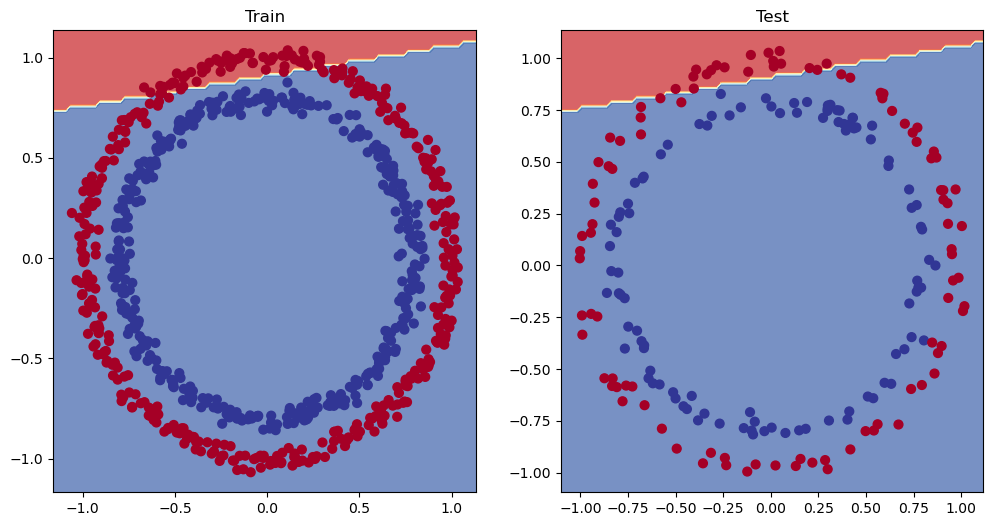

In [23]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_1,X_train,y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_1,X_test,y_test)

In [48]:
class Linear(nn.Module):
    def __init__(self,input_features,output_features,hidden_features):
        super().__init__()
        self.linear_layer1 = nn.Linear(in_features=input_features,out_features=hidden_features)
        self.linear_layer2 = nn.Linear(in_features=hidden_features,out_features=hidden_features)
        self.output_layer = nn.Linear(in_features=hidden_features,out_features=output_features)
        self.relu = nn.ReLU()
        
    def forward(self,X):
        return self.output_layer(self.relu(self.linear_layer2(self.relu(self.linear_layer1(X)))))
        

In [49]:
model_2 = Linear(input_features=2,output_features=1,hidden_features=5)
model_2

Linear(
  (linear_layer1): Linear(in_features=2, out_features=5, bias=True)
  (linear_layer2): Linear(in_features=5, out_features=5, bias=True)
  (output_layer): Linear(in_features=5, out_features=1, bias=True)
  (relu): ReLU()
)

In [28]:
model_2.state_dict()

OrderedDict([('linear_layer1.weight',
              tensor([[-0.2732, -0.5424],
                      [ 0.5802,  0.2037],
                      [ 0.2929,  0.2236],
                      [-0.0123,  0.5534],
                      [-0.5024,  0.0445]])),
             ('linear_layer1.bias',
              tensor([-0.4826,  0.2180, -0.2435,  0.2167, -0.1473])),
             ('linear_layer2.weight',
              tensor([[ 0.3709, -0.2651, -0.2667, -0.2667,  0.4022],
                      [ 0.1490,  0.4303, -0.3691, -0.4436, -0.3499],
                      [-0.3008,  0.1811,  0.1601,  0.3716, -0.2310],
                      [-0.3049,  0.2373, -0.1808,  0.2714, -0.1061],
                      [ 0.2558, -0.3475, -0.2257,  0.1363,  0.0945]])),
             ('linear_layer2.bias',
              tensor([-0.1140,  0.2666,  0.3040, -0.3243, -0.2388])),
             ('output_layer.weight',
              tensor([[ 0.4095, -0.1509, -0.1585, -0.4327, -0.2561]])),
             ('output_layer.bias', tensor(

In [38]:
optimizer1 = torch.optim.SGD(params=model_2.parameters(),lr=0.01)

In [39]:
torch.manual_seed(42)
epochs = 1000
for epoch in tqdm(range(epochs)):
    model_2.train()
    
    
    y_logits = model_2(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))
    
    loss = loss_fn(y_logits,y_train)
    acc = accuracy_fn(y_true=y_train,y_pred = y_pred)
    
    optimizer1.zero_grad()
    loss.backward()
    optimizer1.step()
    
    
    model_2.eval()
    with torch.inference_mode():
        y_pred_test = model_2(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(y_pred_test))
        
        test_loss = loss_fn(y_pred_test,y_test)
        test_acc = accuracy_fn(y_true=y_test,y_pred=test_pred)
        
        
    if epoch % 100 == 0:
        print(f"Epoch : {epoch} | TrainLoss : {loss} | Train Acc : {acc} | Test Loss : {test_loss} | Test Acc : {test_acc}")

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch : 0 | TrainLoss : 0.02217765897512436 | Train Acc : 99.875 | Test Loss : 0.048647135496139526 | Test Acc : 99.0
Epoch : 100 | TrainLoss : 0.02212783321738243 | Train Acc : 99.875 | Test Loss : 0.04857192933559418 | Test Acc : 99.0
Epoch : 200 | TrainLoss : 0.022078193724155426 | Train Acc : 99.875 | Test Loss : 0.04849689081311226 | Test Acc : 99.0
Epoch : 300 | TrainLoss : 0.02202879823744297 | Train Acc : 99.875 | Test Loss : 0.04842216521501541 | Test Acc : 99.0
Epoch : 400 | TrainLoss : 0.0219795610755682 | Train Acc : 99.875 | Test Loss : 0.04834720119833946 | Test Acc : 99.0
Epoch : 500 | TrainLoss : 0.021930553019046783 | Train Acc : 99.875 | Test Loss : 0.04827315732836723 | Test Acc : 99.0
Epoch : 600 | TrainLoss : 0.021881913766264915 | Train Acc : 99.875 | Test Loss : 0.04819966480135918 | Test Acc : 99.0
Epoch : 700 | TrainLoss : 0.021833494305610657 | Train Acc : 99.875 | Test Loss : 0.04812661558389664 | Test Acc : 99.0
Epoch : 800 | TrainLoss : 0.021785221993923187

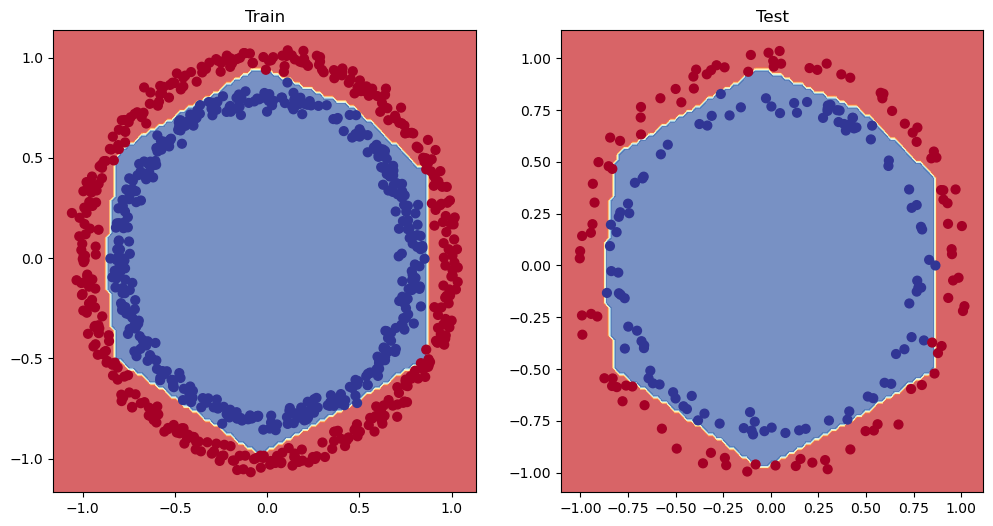

In [40]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_2,X_train,y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_2,X_test,y_test)